# SESSION: Time-domain analyses #4.39. Lowpass filter an ERP

COURSE: Neural signal processing and analysis: Zero to hero

TEACHER: Mike X Cohen, sincxpress.com

**Goal:** Describe goal of notebook

First, do your imports.

In [91]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import mne
import scipy.io

Now, load in the data

In [92]:
# load the laminar data
laminar_data = scipy.io.loadmat('../data/v1_laminar.mat')
srate = np.squeeze(laminar_data["srate"])
timevec = np.squeeze(laminar_data["timevec"])

# reduce the data for convenience
channel = 7-1 # Cohen uses channel 7
data = np.squeeze(laminar_data['csd'][channel,:,:])
data = np.float64(data.T)

Set the cutoff frequency for the low-pass filter.

In [93]:
#cutoff frequency for low-pass filter
lowcut = 20 # in Hz

Create and inspect the filter kernel

Setting up low-pass filter at 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 505 samples (0.662 s)



Text(0.5, 1.0, 'Frequency Domain')

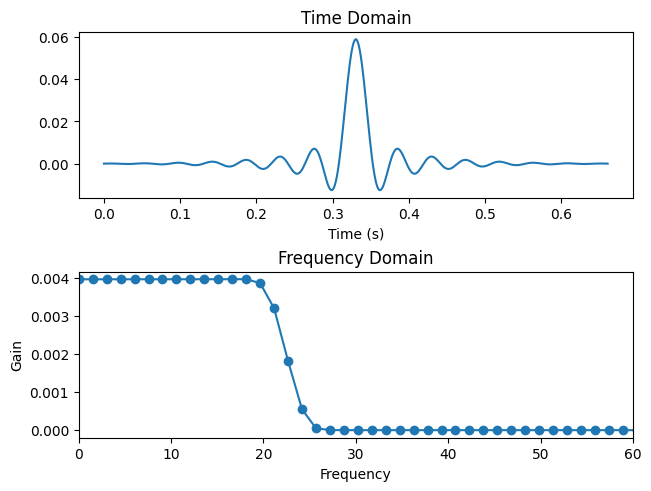

In [94]:
# filter order
filtord = round(18 * (lowcut*1000/srate))
# don't worry about this in MNE, it will automatically optimize it!
# if you want to play around with it, try the numbers 8 and 1000

# create filter
filtkern = mne.filter.create_filter(data=data,sfreq=srate,l_freq=None,h_freq=lowcut)
# note how these parameters differ from the construction in matlab
# use l_freq to indicate your lower cutoff (i.e. a high pass filter)
# use h_freq to indicate your higher cutoff (i.e. a low pass filter)
# it is a little counter intuitive

# use this version to play around with filter order
#filtkern = mne.filter.create_filter(data=None,sfreq=srate,l_freq=None,h_freq=lowcut,filter_length=filtord)



#inspect the filter kernel
fig = plt.figure(layout="constrained")
ax_dict = fig.subplot_mosaic(
    [
        ["time"],
        ["freq"]
    ]
)

ax_dict["time"].plot((range(len(filtkern))/srate),filtkern)
ax_dict["time"].set_xlabel("Time (s)")
ax_dict["time"].set_title("Time Domain")

ax_dict["freq"].magnitude_spectrum(filtkern, Fs = srate, marker = 'o') # convenient matplotlib function for plotting the frequency domain without needing to manually calculate the fourier transform
ax_dict["freq"].set_xlim([0,lowcut*3])
ax_dict["freq"].set_ylabel("Gain")
ax_dict["freq"].set_title("Frequency Domain")

## Option 1: filter the ERP

Setting up low-pass filter at 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 505 samples (0.662 s)



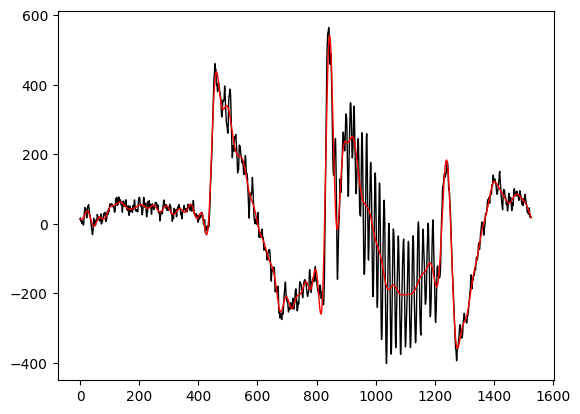

In [95]:
# extract ERP
erp1 = np.mean(data,0)
plt.plot(erp1,"k",linewidth=1)

#apply filter
# you don't pass in the filter kernel that you created.
# instead, use the same parameters
# mne.filter.create_filter(sfreq=srate,l_freq=None,h_freq=lowcut)
erp1 = mne.filter.filter_data(data=erp1,sfreq=srate,l_freq=None,h_freq=lowcut)
plt.plot(erp1,"r",linewidth=1)

## Option 2: filter the single trials

In [100]:
erp2 = np.zeros_like(timevec)

for triali in range(data.shape[0]):
    erp2 = erp2 + mne.filter.filter_data(data=data[triali,:],sfreq=srate,l_freq=None,h_freq=lowcut)

# complete the averaging
erp2 = erp2/data.shape[0]

Setting up low-pass filter at 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 505 samples (0.662 s)

Setting up low-pass filter at 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 505 samples (0.662 s)

Setting up low-pass filter at 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) m

## Option 3: concatenate

Setting up low-pass filter at 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 505 samples (0.662 s)



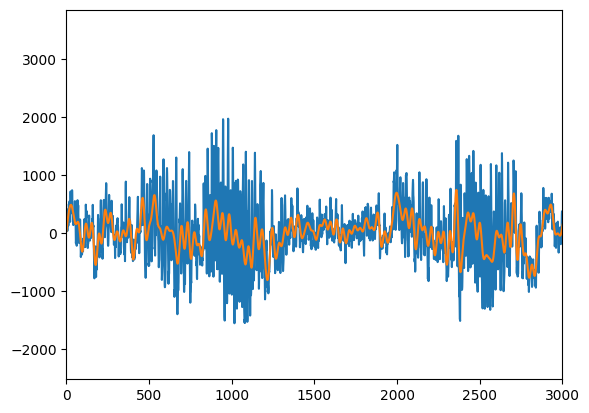

In [105]:
# make one long trial
supertrial = np.reshape(data,[-1])
plt.plot(supertrial)
plt.xlim(0,3000)

#apply filter
supertrial = mne.filter.filter_data(data=supertrial,sfreq=srate,l_freq=None,h_freq=lowcut)
plt.plot(supertrial)

# reshape back and take average
erp3 = np.reshape(supertrial,data.shape)
erp3 = np.mean(erp3,0)


## Now compare

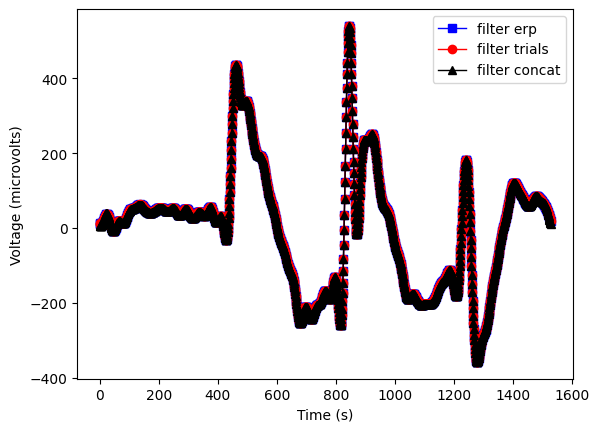

In [118]:
plt.plot(erp1,"bs-",linewidth=1)
plt.plot(erp2,"ro-",linewidth=1)
plt.plot(erp3,"k^-",linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (microvolts)")
plt.legend(["filter erp","filter trials","filter concat"])

#use this to zoom
#plt.xlim(-10,50)
#plt.ylim(-100,100)